In [47]:
from google.colab import drive

# 1. Mount Google Drive to the default location.
drive.mount('/content/drive')

#2.Acess to the dataset on drive
train_path = "/content/drive/MyDrive/train.csv"
valid_path = "/content/drive/MyDrive/valid.csv"
test_path = "/content/drive/MyDrive/test.csv"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
!pip install imbalanced-learn


In [126]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import string
import os
import pickle
import numpy as np
import random
# Set id
student_id = 2312003
np.random.seed(student_id)
random.seed(student_id)



In [127]:
!ls /content/drive/MyDrive/Text_Analytics


model  test.csv  train.csv  valid.csv


In [128]:
data_path = "/content/drive/MyDrive/Text_Analytics/"


Preprocess data

In [129]:
# Load datasets
train_df = pd.read_csv(data_path + "train.csv")
valid_df = pd.read_csv(data_path + "valid.csv")
test_df = pd.read_csv(data_path + "test.csv")

# Preprocessing function
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
import string

nltk.download('stopwords')
nltk.download('wordnet')

def preprocess_text(df, text_column="text"):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))

    def clean_text(text):
        text = text.lower()
        text = ''.join([char for char in text if char not in string.punctuation])
        words = text.split()
        words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
        return ' '.join(words)

    df[text_column] = df[text_column].fillna("").apply(clean_text)
    return df

# Apply preprocessing
train_df = preprocess_text(train_df)
valid_df = preprocess_text(valid_df)
test_df = preprocess_text(test_df)

# Labels mapping
y_train = train_df['sentiment'].map({'negative': 0, 'positive': 1})
y_valid = valid_df['sentiment'].map({'negative': 0, 'positive': 1})


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Vectorize text using TF-IDF

In [130]:
# Initialize TF-IDF
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words='english')

# Transform datasets
X_train = tfidf.fit_transform(train_df['text'])
X_valid = tfidf.transform(valid_df['text'])
X_test = tfidf.transform(test_df['text'])

print("TF-IDF Feature Shapes:")
print(f"Train: {X_train.shape}, Validation: {X_valid.shape}, Test: {X_test.shape}")


TF-IDF Feature Shapes:
Train: (3681, 10000), Validation: (454, 10000), Test: (409, 10000)


Handle class imbalance with SMOTE

In [131]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=56789)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, train_df['sentiment'])

# Check the new class distribution
print("Class Distribution After SMOTE:", Counter(y_train_balanced))


Class Distribution After SMOTE: Counter({'positive': 3031, 'negative': 3031})


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Train Naive Bayes- a GENERATIVE MODEL

Validation Results (Naive Bayes):
              precision    recall  f1-score   support

           0       1.00      0.01      0.02        81
           1       0.82      1.00      0.90       373

    accuracy                           0.82       454
   macro avg       0.91      0.51      0.46       454
weighted avg       0.85      0.82      0.75       454



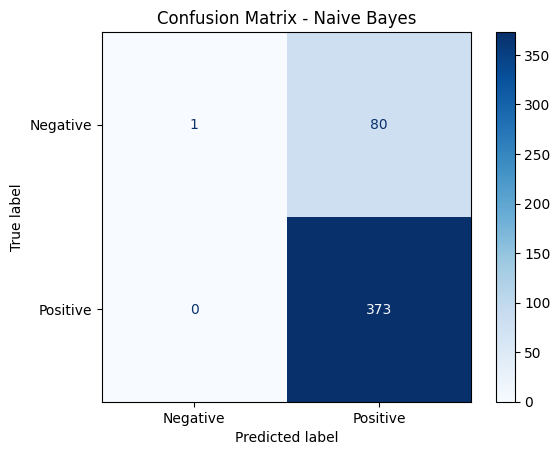

In [132]:
# Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Save model
with open(output_path + "Model_gen/naive_bayes.pkl", "wb") as f:
    pickle.dump(nb_model, f)

# Validate Naive Bayes
valid_preds_nb = nb_model.predict(X_valid)
print("Validation Results (Naive Bayes):")
print(classification_report(y_valid, valid_preds_nb))

# Confusion Matrix
cm_nb = confusion_matrix(y_valid, valid_preds_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Negative', 'Positive'])
disp_nb.plot(cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes")
plt.show()


Train Logistic Regression-Discriminative modle

Validation Results (Logistic Regression):
              precision    recall  f1-score   support

           0       0.56      0.47      0.51        81
           1       0.89      0.92      0.90       373

    accuracy                           0.84       454
   macro avg       0.72      0.69      0.71       454
weighted avg       0.83      0.84      0.83       454



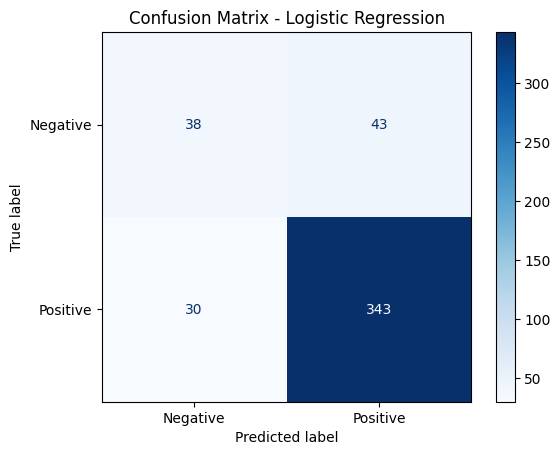

In [133]:
from sklearn.model_selection import GridSearchCV

# Grid search for Logistic Regression
lr_params = {'C': [0.1, 1, 10], 'solver': ['liblinear', 'lbfgs'], 'class_weight': [None, 'balanced']}
lr_grid = GridSearchCV(LogisticRegression(max_iter=500), lr_params, cv=5, scoring='f1_macro')
lr_grid.fit(X_train, y_train)

# Save best Logistic Regression model
best_lr_model = lr_grid.best_estimator_
with open(output_path + "Model_dis/logistic_regression.pkl", "wb") as f:
    pickle.dump(best_lr_model, f)

# Validate Logistic Regression
valid_preds_lr = best_lr_model.predict(X_valid)
print("Validation Results (Logistic Regression):")
print(classification_report(y_valid, valid_preds_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_valid, valid_preds_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Negative', 'Positive'])
disp_lr.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [137]:
# Test predictions
test_preds_nb = nb_model.predict(X_test)
test_preds_lr = best_lr_model.predict(X_test)

# Save predictions to test.csv
test_df['out_label_model_gen'] = test_preds_nb
test_df['out_label_model_dis'] = test_preds_lr
test_df.to_csv(data_path + "Test.csv", index=False)

print("Test predictions saved at:", data_path + "Test.csv")


Test predictions saved at: /content/drive/MyDrive/Text_Analytics/Test.csv
